In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import os

In [2]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head(20)

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 08:06:17-04:00,A


In [3]:
df['date'].isnull().sum()

np.int64(0)

## Date Column Clarification
- Initial datetime conversion attempts appeared to produce a large number of null values.
- Further investigation revealed that the dataset itself does not contain missing date values.
- The issue was likely caused by inconsistent datetime parsing or notebook execution order during preprocessing.
- The dataset contains mixed timezone/date formatting styles, which may require normalization during later preprocessing stages.
- Since all records contain valid date information, comprehensive time-series analysis remains feasible.

In [4]:
df.shape

(1407328, 6)

In [5]:
df['date'].astype(str).sample(30)

178295     2009-08-16 00:00:00
495457     2020-04-29 00:00:00
235984     2019-06-12 00:00:00
697451     2013-04-10 00:00:00
285719     2020-02-26 00:00:00
1178528    2020-03-12 00:00:00
1145655    2011-09-30 00:00:00
1147699    2013-02-28 00:00:00
1293331    2011-11-28 00:00:00
896472     2015-04-01 00:00:00
171620     2017-02-02 00:00:00
109289     2015-02-02 00:00:00
1208069    2015-04-24 00:00:00
1315074    2013-10-03 00:00:00
579052     2015-07-13 00:00:00
1187373    2019-09-18 00:00:00
563697     2012-11-05 00:00:00
175193     2017-01-30 00:00:00
825120     2019-08-08 00:00:00
90688      2011-11-14 00:00:00
191459     2012-02-23 00:00:00
1050641    2012-10-25 00:00:00
73431      2018-08-27 00:00:00
1058137    2011-07-06 00:00:00
1401217    2015-01-07 00:00:00
1386423    2018-10-23 00:00:00
1366994    2017-09-28 00:00:00
1041186    2009-11-13 00:00:00
110863     2018-12-20 00:00:00
787035     2012-06-20 00:00:00
Name: date, dtype: str

In [6]:
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

This is the solution for the dataset.

What it does:

detects each row’s format individually
handles timezone-aware rows
handles timezone-naive rows
converts everything into UTC consistently

In [7]:
df['date'].dtype

datetime64[us, UTC]

In [8]:
df['date'].astype(str).sample(30)

896175     2011-09-08 00:00:00+00:00
807201     2011-03-23 00:00:00+00:00
1173773    2019-08-02 00:00:00+00:00
103052     2019-01-14 00:00:00+00:00
588196     2016-01-15 00:00:00+00:00
516491     2012-04-17 00:00:00+00:00
418789     2013-02-06 00:00:00+00:00
46270      2017-09-13 00:00:00+00:00
61437      2014-03-06 00:00:00+00:00
1062341    2019-10-11 00:00:00+00:00
32970      2020-03-30 00:00:00+00:00
267645     2017-10-20 00:00:00+00:00
869568     2018-12-07 00:00:00+00:00
13688      2011-01-23 00:00:00+00:00
706618     2018-02-01 00:00:00+00:00
834750     2015-08-20 00:00:00+00:00
682633     2016-11-04 00:00:00+00:00
780643     2015-01-29 00:00:00+00:00
733394     2011-07-20 00:00:00+00:00
1356152    2016-04-15 00:00:00+00:00
225633     2016-12-29 00:00:00+00:00
749720     2015-06-03 00:00:00+00:00
314726     2018-09-27 00:00:00+00:00
506648     2013-03-06 00:00:00+00:00
285758     2019-09-02 00:00:00+00:00
583468     2013-04-24 00:00:00+00:00
174497     2019-09-05 00:00:00+00:00
1

In [9]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour

In [10]:
df.to_csv('cleaned_financial_news.csv', index=False)

In [11]:
df[['year', 'month', 'hour']].head(20)

,year,month,hour
0,2020,6,14
1,2020,6,14
2,2020,5,8
3,2020,5,16
4,2020,5,15
5,2020,5,15
6,2020,5,13
7,2020,5,13
8,2020,5,12
9,2020,5,12


In [12]:
df.shape

(1407328, 10)

IMPORTANT CONCLUSION

The dataset contains: both precise timestamps and date-only entries

This means: hourly analysis is still possible BUT midnight (0) is artificially inflated

So later: if we analyze publishing hours, we MUST mention that hour 0 may partly represent missing-time records rather than actual midnight publishing. 

We have now

inspected structure
cleaned datetime inconsistencies
verified duplicates
explored publishers
explored stock identifiers
standardized dates
created derived time features
documented limitations


In [13]:
df['headline_length'] = df['headline'].str.len()

In [14]:
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [17]:
df[df['headline_length'] == df['headline_length'].max()]['headline'].iloc[0]

'JinkoSolar Tiger Pro Series Receives World\'s First IEC 61701 Ed. 3 (FDIS) Certification for Salt Mist Corrosion Standards JinkoSolar Holding Co., Ltd. (the "Company," or "JinkoSolar") (NYSE:JKS), one of the largest and most innovative solar module manufacturers in the world, today announced that its innovative Tiger Pro Series of high-efficiency modules received the world\'s first IEC 61701 Ed. 3 (FDIS) certification for salt mist corrosion test issued by TÜV Nord AG, an independent provider of technical ser'

1. Average headline length ≈ 73 characters

This suggests:

headlines are generally concise
publishers likely optimize for:
quick reading
attention grabbing
fast financial updates

Financial headlines are usually designed to:

communicate information quickly
summarize market-moving events efficiently

That matches what we expect in finance/news media.

- Median = 64 so median < mean The distribution is right-skewed. Meaning: most headlines are moderate length but some very long headlines pull the average upward. This is VERY common in news datasets.

- Standard deviation ≈ 40, This is relatively large. Meaning: headline sizes vary a lot some headlines are extremely short others are detailed/complex
This tells us: publishers do not follow a strict headline size standard different news types may require different headline styles Example: breaking news → short AND analysis/report → long

- Minimum 3 characters and maximum 5

Head line length Analysis

Headline lengths were analyzed to understand the structure and style of financial news reporting. The average headline length was approximately 73 characters, while the median was 64 characters, indicating that most headlines are relatively concise.

The distribution appears right-skewed, suggesting that although many headlines are short-to-medium in length, a smaller number of very long headlines increase the average. This reflects variation in reporting styles, where some headlines provide brief breaking-news summaries while others include detailed contextual information.

The standard deviation of approximately 40 characters indicates substantial variability in headline formatting across publishers and article types.

Extremely short and extremely long headlines were identified and investigated further to determine whether they represent meaningful content, abbreviations, or potential data anomalies.

The headline length distribution provides insight into how financial information is communicated rapidly and efficiently in news media.

Extremely long headlines may indicate:

- Detailed financial summaries like earnings reports, merger announcements, FDA trial details. These naturally require longer headlines.
- Data formatting issues like duplicated text, HTML fragments, broken scraping, multiple headlines concatenated. This is a DATA QUALITY concern.
- Different publisher styles. Some publishers use compact headlines and others use descriptive, article-summary-like headlines, which helps characterize publishers later.

In [18]:
df[df['headline_length'] <= 5]['headline'].head(20)

127835     Amgen
225560     Merck
239390     China
455544     Japan
530954       SPY
530955       SRS
602684       J.P
657289     Roche
658459      IMAX
678958       AMJ
849109     Merck
912819       J.P
984798       PCP
1047479      QID
1085030     GE's
1154786    China
1179797      SPY
1191387      SUN
1191388      SUN
1228292      TJX
Name: headline, dtype: str

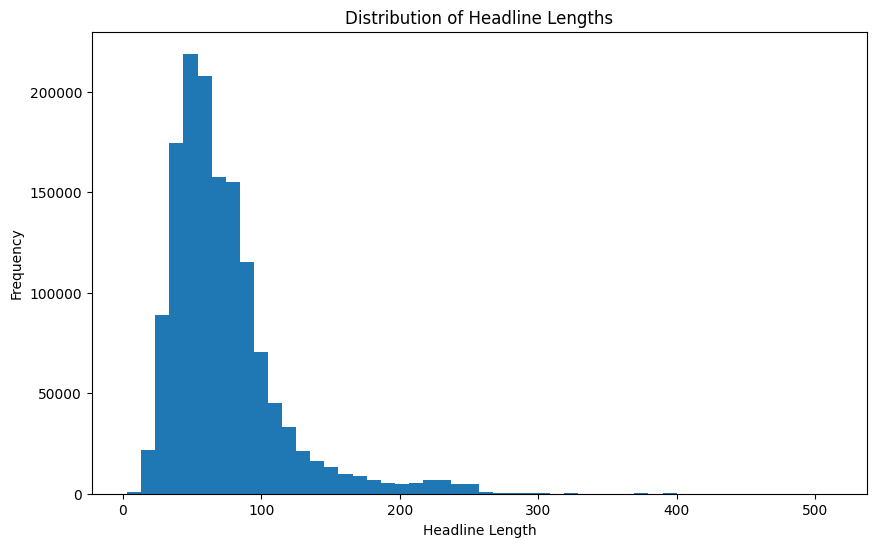

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df['headline_length'], bins=50)

plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')
plt.show()

As we can understand from the graph, the typical financial headline is around 50 - 90 characters. That is the length where most headlines cluster. It is a right-skewed didtribution. Some outliers exist representing detailed news or data anomalies. Therefore, the concetration of headlines around moderate length suggests publishers optimize for rapid information delivery while retaining enough detail to convey financially significant events.

In [23]:
top_publishers = df['publisher'].value_counts().head(15)

print(top_publishers)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


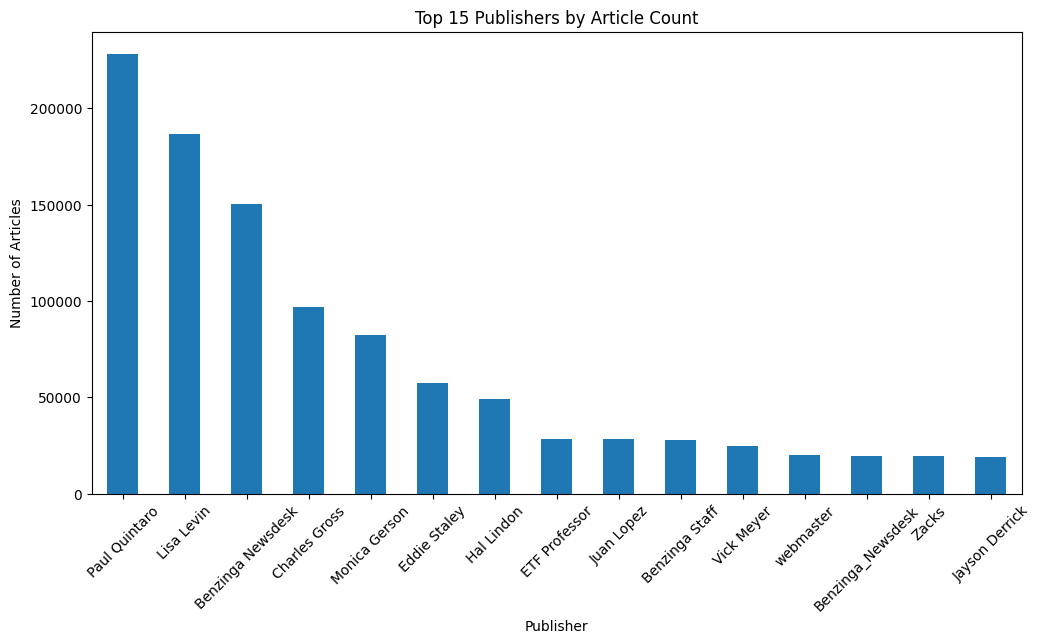

In [24]:
top_publishers.plot(kind='bar', figsize=(12,6))

plt.title('Top 15 Publishers by Article Count')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45)
plt.show()

In [25]:
email_publishers = df[df['publisher'].str.contains('@', na=False)]

email_publishers['domain'] = email_publishers['publisher'].str.split('@').str[-1]

print(email_publishers['domain'].value_counts().head(15))

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


Publisher analysis revealed substantial variation in article contribution frequencies across news sources. A relatively small number of publishers appear to contribute a disproportionately large share of the dataset, suggesting possible concentration in financial news dissemination.

The dataset contains a mixture of publisher identities, including institutional organizations (e.g., financial news desks and insights teams) as well as individual contributor names. This indicates that the dataset captures both centralized newsroom publishing and author-level reporting activity.

Email-based publisher entries were additionally analyzed by extracting organizational domains, enabling identification of institutional contribution patterns. Such domain-level analysis may help distinguish between independent contributors, media organizations, and automated news distribution systems.

Differences in publisher activity may later influence topic prevalence, reporting styles, sentiment patterns, and temporal publishing behavior.

In [26]:
articles_per_year = df['year'].value_counts().sort_index()

print(articles_per_year)

year
2009     11489
2010     81319
2011    131322
2012    122649
2013    121529
2014    134859
2015    135295
2016    141892
2017    124456
2018    146924
2019    150380
2020    105214
Name: count, dtype: int64


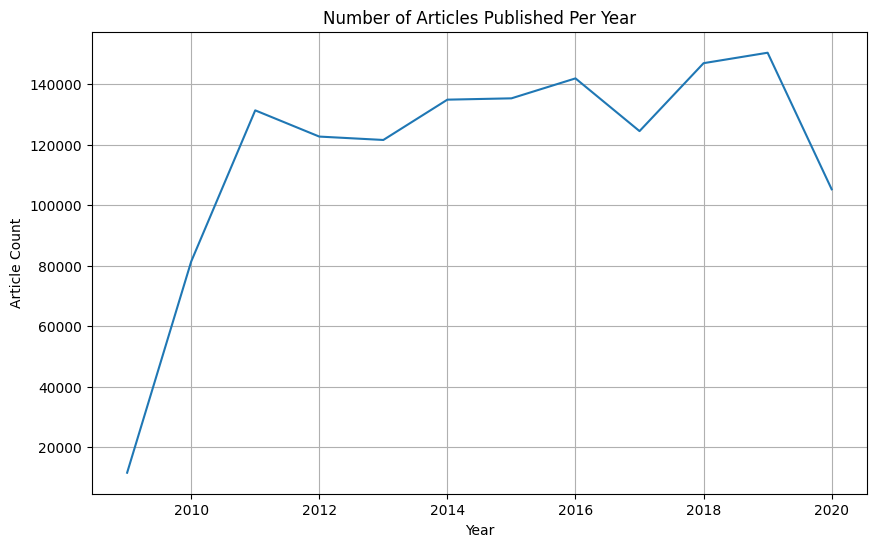

In [27]:
articles_per_year.plot(figsize=(10,6))

plt.title('Number of Articles Published Per Year')
plt.xlabel('Year')
plt.ylabel('Article Count')

plt.grid(True)
plt.show()

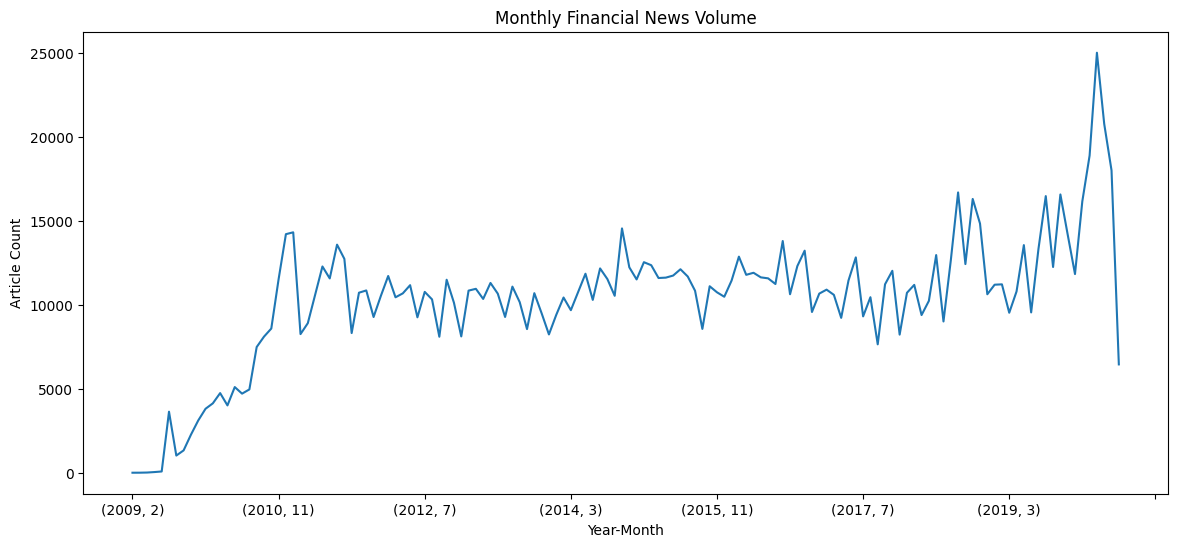

In [28]:
articles_per_month = df.groupby(['year', 'month']).size()

articles_per_month.plot(figsize=(14,6))

plt.title('Monthly Financial News Volume')
plt.xlabel('Year-Month')
plt.ylabel('Article Count')

plt.show()

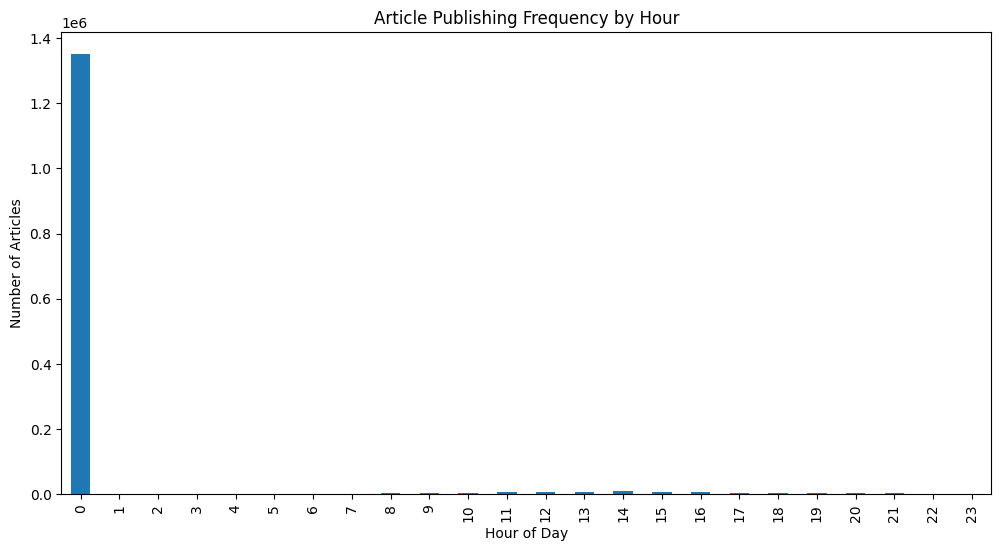

In [29]:
hour_counts = df['hour'].value_counts().sort_index()

hour_counts.plot(kind='bar', figsize=(12,6))

plt.title('Article Publishing Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')

plt.show()

THIS IMPLIES a data quality limitation.

It means many records preserve only publication dates
exact hourly timing is unavailable for a large portion of articles therefore intraday/hourly analysis is partially distorted
HOWEVER we've found the dataset to be perfectly usable for daily and monthly trends, yearly patterns, NLP,publisher analysis, and stock-news relationship analysis

It mainly weakens in being precise on “what hour affects stock movement” analysis.

The hourly publication distribution revealed a disproportionately large spike at hour 00:00 (midnight), while the remaining hourly values appeared comparatively very small. Further investigation showed that a substantial portion of the dataset contains records with missing publication times, where only the date was preserved. During datetime conversion, these records defaulted to 00:00:00 UTC, creating an artificial concentration at midnight. This indicates that the dataset contains incomplete timestamp granularity for many articles. Consequently, while long-term temporal analyses such as yearly or monthly trends remain reliable, precise intraday publishing-time analysis may be partially distorted and should be interpreted cautiously.

Time Series Analysis Report

Temporal analysis revealed that financial news publication activity varies substantially across years and months. Overall article volume appears to increase over time, potentially reflecting growth in digital financial journalism, algorithmic trading systems, and real-time market reporting practices.

Monthly publication patterns indicate periods of elevated news activity that may correspond to significant economic events, earnings seasons, market volatility, or major corporate developments. While precise causal relationships require external market-event validation, the observed spikes suggest strong temporal clustering in financial reporting behavior.

Analysis of publication hours showed that many articles were released during specific periods of the day, potentially aligning with trading hours, earnings announcements, and pre-market reporting cycles. However, a substantial number of records appear at hour 0, likely due to entries containing dates without exact publication times. This should be interpreted carefully during fine-grained temporal analysis.

The dataset demonstrates clear temporal structure suitable for later stock-news relationship studies and event-driven financial analysis.

In [ ]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['headline'])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    'word': words,
    'count': counts
}).sort_values(by='count', ascending=False)

print(keyword_df)

          word   count
18          vs  162099
15      stocks  161776
6          est  140604
5          eps  128897
7       market  120558
14      shares  114313
12     reports  108710
17      update   91723
4     earnings   87399
13       sales   79645
1     benzinga   74516
10          pt   73068
19        week   69572
0    announces   66591
9        price   64407
2          buy   64371
8          mid   62263
3   downgrades   61959
16     trading   61182
11      raises   57802


NLP / KEYWORD ANALYSIS REPORT (FORMAL)
The keyword frequency analysis revealed strong patterns characteristic of financial and market-oriented news reporting. Frequently occurring terms such as stocks, shares, market, trading, earnings, sales, price, and reports indicate that the dataset is heavily focused on stock market activity, corporate performance, and investor-relevant financial events. The repeated appearance of terms like buy, raises, downgrades, and pt (price target) suggests that analyst recommendations and valuation updates form a significant portion of the news coverage. Additionally, keywords such as eps (earnings per share) and est (estimates) confirm that quarterly earnings announcements and financial forecasting are dominant themes throughout the dataset.
The analysis also revealed the strong presence of platform-specific terminology such as benzinga, indicating that a large proportion of articles originate from financial news providers specializing in market-moving updates and investor sentiment. Overall, the extracted keywords demonstrate that the dataset captures highly market-sensitive information closely tied to trading behavior, earnings performance, analyst opinions, and company valuation events. These characteristics make the dataset particularly suitable for downstream tasks such as financial sentiment analysis, event-driven forecasting, market trend analysis, and stock behavior prediction.

In [36]:
keywords = vectorizer.get_feature_names_out()
word_counts = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    'word': keywords,
    'count': word_counts
})

keyword_df = keyword_df.sort_values(by='count', ascending=False)

print(keyword_df)

          word   count
18          vs  162099
15      stocks  161776
6          est  140604
5          eps  128897
7       market  120558
14      shares  114313
12     reports  108710
17      update   91723
4     earnings   87399
13       sales   79645
1     benzinga   74516
10          pt   73068
19        week   69572
0    announces   66591
9        price   64407
2          buy   64371
8          mid   62263
3   downgrades   61959
16     trading   61182
11      raises   57802


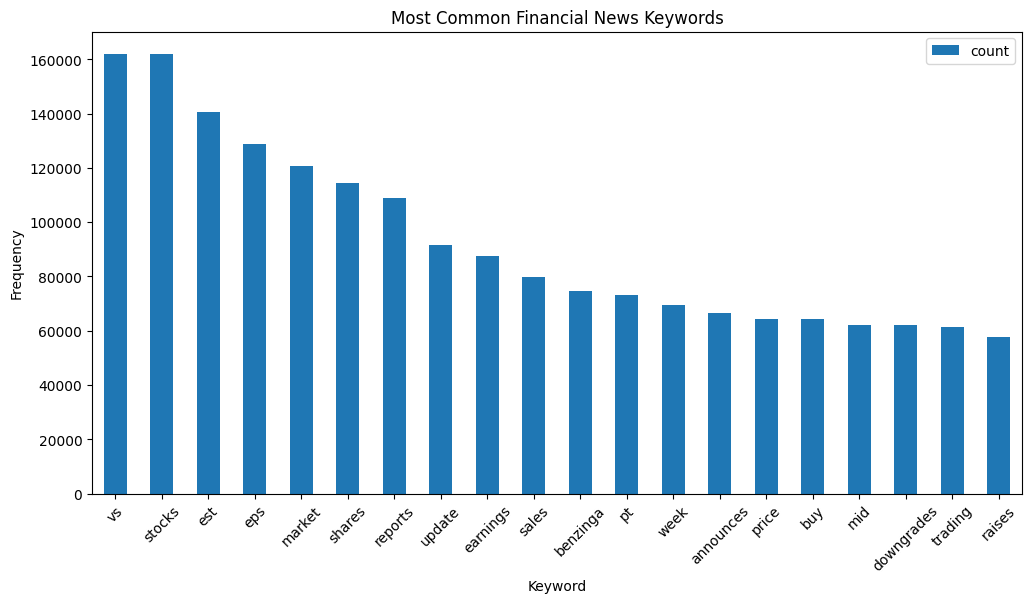

In [37]:
keyword_df.plot(
    x='word',
    y='count',
    kind='bar',
    figsize=(12,6)
)

plt.title('Most Common Financial News Keywords')
plt.xlabel('Keyword')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

Keyword extraction revealed recurring financial terminology strongly associated with market reporting, corporate performance, investment analysis, and stock valuation activities. Frequently occurring terms such as earnings, shares, market, target, reports, and stock suggest that the dataset is heavily oriented toward investment-related developments and corporate financial events.

The prevalence of analytical and market-oriented vocabulary indicates that much of the reporting focuses on actionable financial information, including earnings announcements, analyst recommendations, regulatory developments, and stock performance updates.

The extracted keywords also suggest that the dataset is appropriate for downstream sentiment analysis and event-driven stock movement studies, as many headlines appear directly linked to financially significant corporate events and investor decision-making processes.

In [38]:
df['headline'].sample(20).tolist()

['Stifel Nicolaus Downgrades WMS Industries Inc. to Hold, Removes $20.00 PT',
 'Top 4 Stocks In The Computer Based Systems Industry With The Highest ROE',
 'Randgold Resources Reports Q4 EPS $1.26 vs $1.23 Est; Revenues $311.5M vs $344.15M Est',
 'Benzinga Market Primer: Tuesday, January 15',
 'U.S. Stocks Tumble Following Malaysian Plane Crash; AutoNation Falls On Downbeat Earnings',
 'eBay Q1 Adj. EPS $0.53, Inline, Sales $2.6B Beats $2.59B Est.',
 'J.P Morgan Downgrades Fortinet To Neutral',
 'Jefferies Maintains Hold Rating, $28 PT On JCOM',
 'Galena Begins RELIEF Patient Registry for Abstral Sublingual Tablets',
 "Suntrust's Peck Believes One Concern Will Be Impact Of SoftBank and Yahoo Stakes Coming To Market, With Cross Holdings Of Yahoo, Yahoo Japan, SoftBank, And Alibaba Cross Holdings",
 'Alibaba Ties Up With Audi, Renault And Honda For AI-powered Tmall Genie Auto Smart Speakers',
 'Wells Fargo Revises Earnings Estimates Up (BC, ED, MHK, GDP, MGA)',
 'Stocks to Watch for 6/28

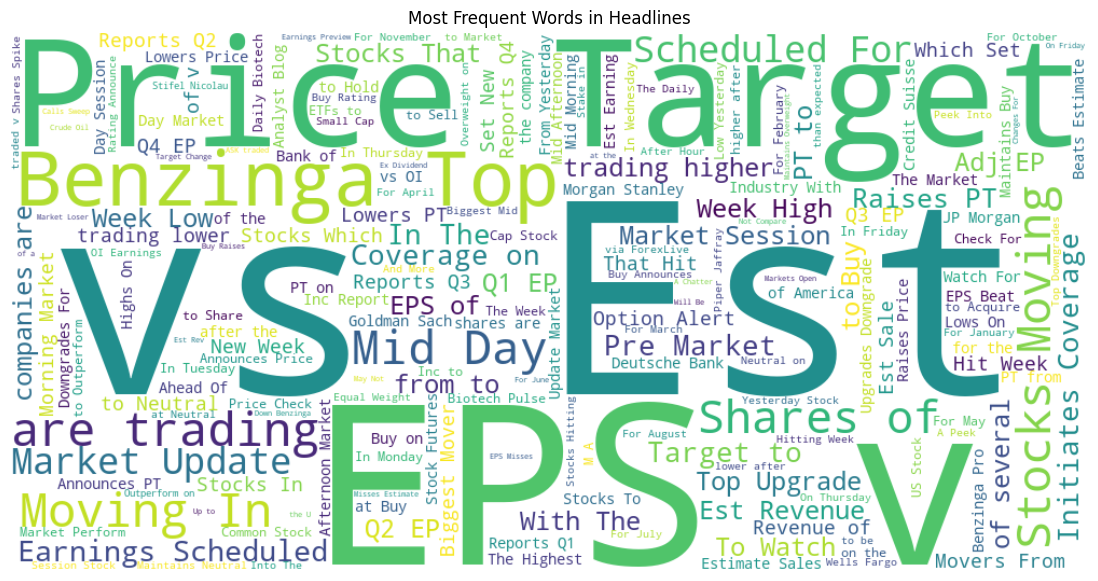

In [41]:
text = ' '.join(df['headline'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords='english'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Headlines')
plt.show()